In [ ]:
from google.colab import files
files.upload()  # kaggle.json'ı seç

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mervenurakmakolu","key":"25b5b90ec6a4e66ee0664dd77d2622fd"}'}

In [ ]:
import os
os.makedirs("/root/.kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 600)

# Dataseti indir
os.system("kaggle datasets download -d abdallahalidev/plantvillage-dataset")

# Zip'i aç
import zipfile
with zipfile.ZipFile("plantvillage-dataset.zip", "r") as z:
    z.extractall("plantvillage")

print("Tamamlandı!")

Tamamlandı!


In [ ]:
import os

base_dir = "plantvillage/plantvillage dataset/color"

siniflar = os.listdir(base_dir)
print(f"Toplam sınıf sayısı: {len(siniflar)}")
print("\nİlk 10 sınıf:")
for s in siniflar[:10]:
    n = len(os.listdir(os.path.join(base_dir, s)))
    print(f"  {s}: {n} görüntü")

Toplam sınıf sayısı: 38

İlk 10 sınıf:
  Peach___healthy: 360 görüntü
  Raspberry___healthy: 371 görüntü
  Potato___healthy: 152 görüntü
  Squash___Powdery_mildew: 1835 görüntü
  Corn_(maize)___Common_rust_: 1192 görüntü
  Tomato___Bacterial_spot: 2127 görüntü
  Tomato___Tomato_mosaic_virus: 373 görüntü
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513 görüntü
  Pepper,_bell___Bacterial_spot: 997 görüntü
  Tomato___Tomato_Yellow_Leaf_Curl_Virus: 5357 görüntü


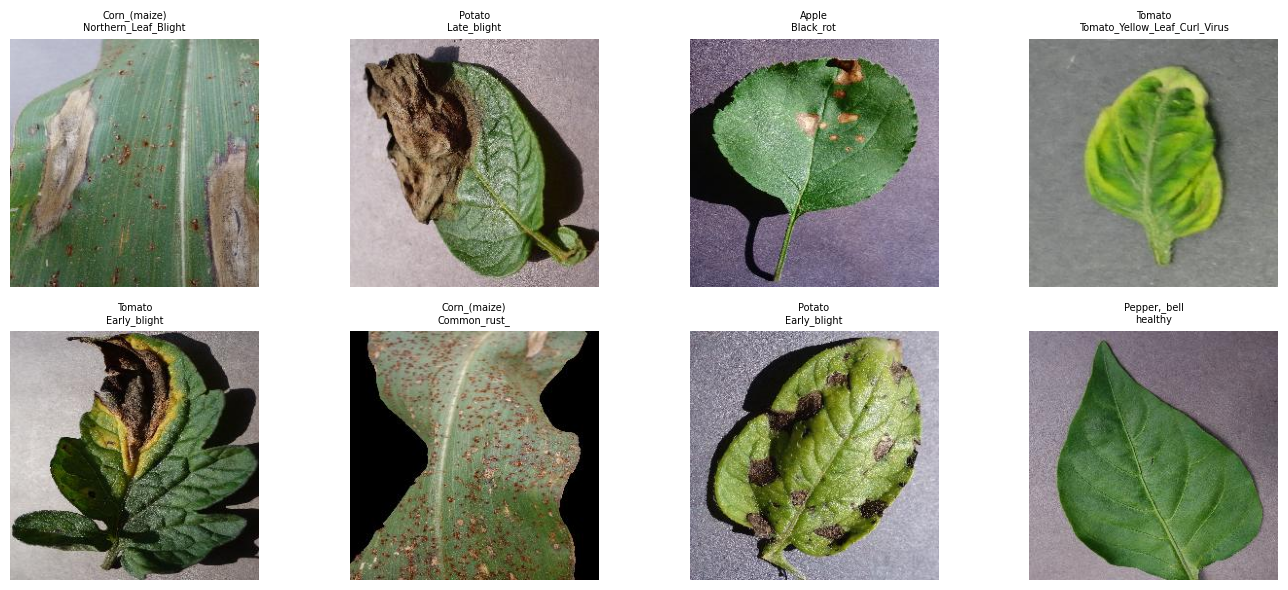

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random, os

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

# 8 farklı sınıftan rastgele birer görüntü göster
secilen = random.sample(siniflar, 8)

for i, sinif in enumerate(secilen):
    sinif_yolu = os.path.join(base_dir, sinif)
    goruntu = random.choice(os.listdir(sinif_yolu))
    img = mpimg.imread(os.path.join(sinif_yolu, goruntu))
    axes[i].imshow(img)
    axes[i].set_title(sinif.replace("___", "\n"), fontsize=7)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.preprocessing import LabelEncoder
import os

def goruntu_ozellik_cikart(img_path):
    # Görüntüyü oku ve yeniden boyutlandır
    img = cv2.imread(img_path)
    img = cv2.resize(img, (128, 128))

    # 1. Renk histogramı (RGB her kanal için)
    hist_r = np.histogram(img[:,:,0], bins=32, range=(0,256))[0]
    hist_g = np.histogram(img[:,:,1], bins=32, range=(0,256))[0]
    hist_b = np.histogram(img[:,:,2], bins=32, range=(0,256))[0]

    # 2. Ortalama ve standart sapma
    ortalama = img.mean(axis=(0,1))
    std = img.std(axis=(0,1))

    # 3. HOG özellikleri
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hog_feat = hog(gray, orientations=8, pixels_per_cell=(16,16),
                   cells_per_block=(1,1), feature_vector=True)

    # Hepsini birleştir
    return np.concatenate([hist_r, hist_g, hist_b, ortalama, std, hog_feat])

# Veriyi yükle (her sınıftan max 200 görüntü al - hız için)
X, y = [], []
for sinif in siniflar:
    sinif_yolu = os.path.join(base_dir, sinif)
    goruntular = os.listdir(sinif_yolu)[:200]
    for g in goruntular:
        try:
            ozellik = goruntu_ozellik_cikart(os.path.join(sinif_yolu, g))
            X.append(ozellik)
            y.append(sinif)
        except:
            pass

X = np.array(X)
y = np.array(y)

print(f"Toplam örnek: {len(X)}")
print(f"Her örneğin özellik sayısı: {X.shape[1]}")
print(f"Sınıf sayısı: {len(set(y))}")

Toplam örnek: 7552
Her örneğin özellik sayısı: 614
Sınıf sayısı: 38


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import pickle

# Etiketleri sayıya çevir
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Eğitim / test olarak böl (%80 eğitim, %20 test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Feature selection — en iyi 100 özelliği seç
selector = SelectKBest(f_classif, k=100)
X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel = selector.transform(X_test)

print(f"Seçilen özellik sayısı: {X_train_sel.shape[1]}")

# Model eğitimi
print("Model eğitiliyor...")
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_sel, y_train)

# Test
y_pred = model.predict(X_test_sel)
acc = accuracy_score(y_test, y_pred)
print(f"\nModel doğruluğu: %{acc*100:.2f}")

# Modeli kaydet
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)
with open("selector.pkl", "wb") as f:
    pickle.dump(selector, f)
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("Model kaydedildi!")

Seçilen özellik sayısı: 100
Model eğitiliyor...

Model doğruluğu: %70.48
Model kaydedildi!


In [ ]:
# Daha güçlü model deneyelim
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.svm import SVC

# 1. Random Forest ama daha fazla ağaç ile
model2 = RandomForestClassifier(
    n_estimators=200,      # 100 yerine 200 ağaç
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
model2.fit(X_train_sel, y_train)
y_pred2 = model2.predict(X_test_sel)
acc2 = accuracy_score(y_test, y_pred2)
print(f"Random Forest (200 ağaç): %{acc2*100:.2f}")

# 2. SVM dene
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

svm = SVC(kernel='rbf', C=10, random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM: %{acc_svm*100:.2f}")

# En iyisini kaydet
best_acc = max(acc2, acc_svm)
print(f"\nEn iyi doğruluk: %{best_acc*100:.2f}")

Random Forest (200 ağaç): %71.14
SVM: %71.81

En iyi doğruluk: %71.81


SVM modeli kaydedildi!


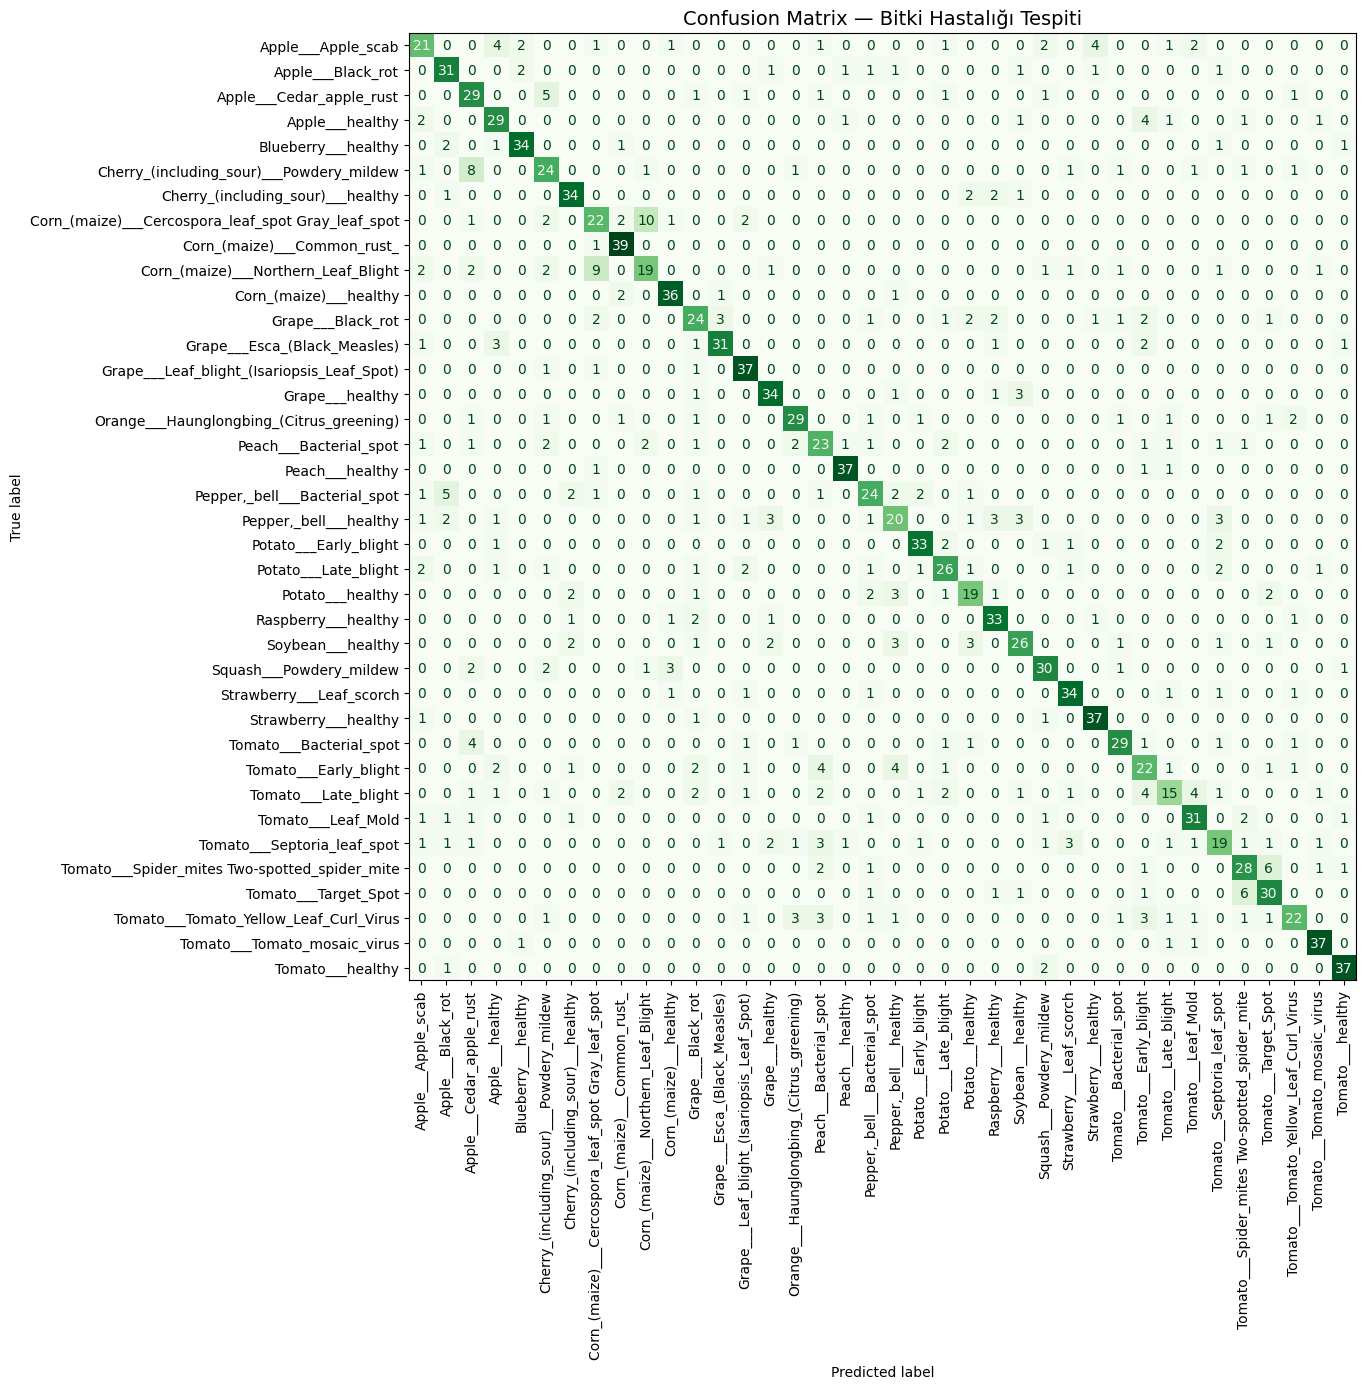

Confusion matrix kaydedildi!


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pickle

# SVM'i kaydet
with open("model.pkl", "wb") as f:
    pickle.dump(svm, f)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("SVM modeli kaydedildi!")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)
fig, ax = plt.subplots(figsize=(16, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False, cmap="Greens")
ax.set_title("Confusion Matrix — Bitki Hastalığı Tespiti", fontsize=14)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix kaydedildi!")

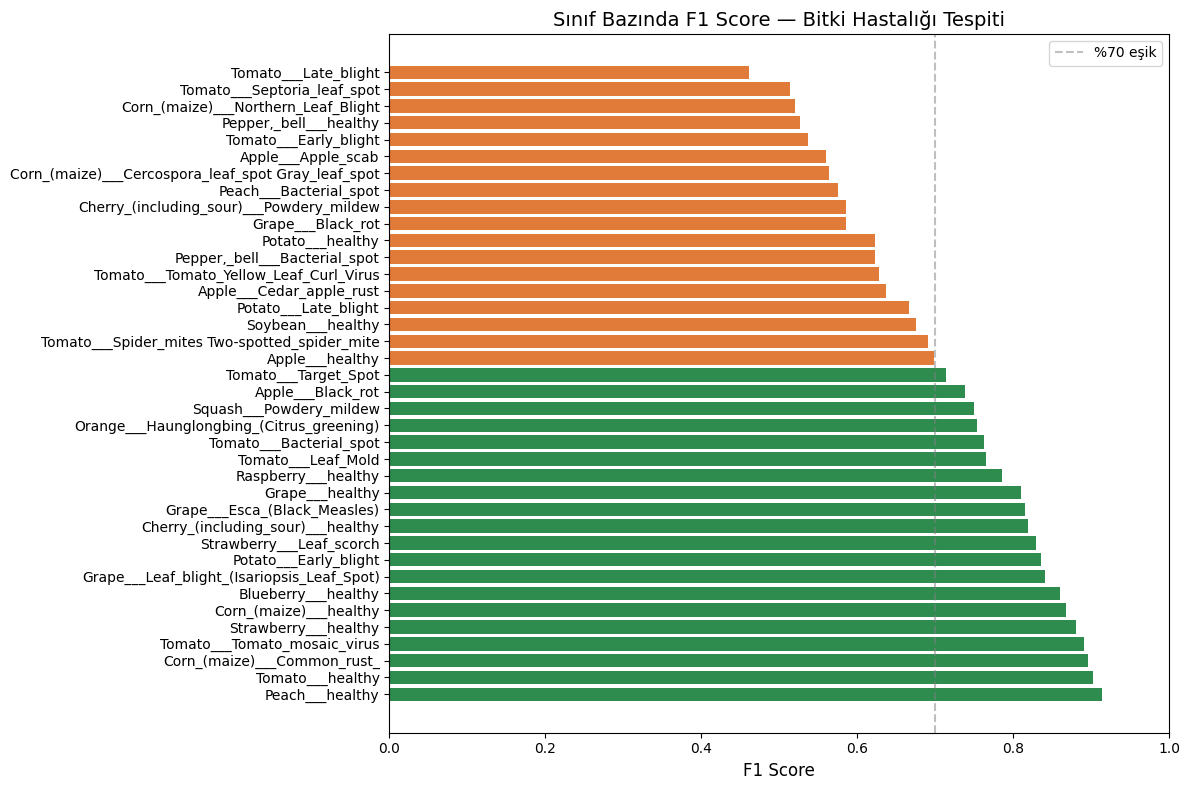


Genel Accuracy: %71.81
Ortalama F1: 0.71

En iyi 3 sınıf:
Peach___healthy                0.913580
Tomato___healthy               0.902439
Corn_(maize)___Common_rust_    0.896552
Name: f1-score, dtype: float64

En zor 3 sınıf:
Corn_(maize)___Northern_Leaf_Blight    0.520548
Tomato___Septoria_leaf_spot            0.513514
Tomato___Late_blight                   0.461538
Name: f1-score, dtype: float64


In [ ]:
# En iyi 20 tahmini gösteren bar chart
from sklearn.metrics import classification_report
import pandas as pd

# Sınıf bazında başarı oranları
report = classification_report(y_test, y_pred_svm,
                                target_names=le.classes_,
                                output_dict=True)
df_report = pd.DataFrame(report).T
df_sinif = df_report[:-3]  # summary satırlarını çıkar

# En iyi 10 ve en kötü 10 sınıfı göster
df_sinif = df_sinif.sort_values("f1-score", ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
renkler = ["#2d8c4e" if f >= 0.7 else "#e07b39" for f in df_sinif["f1-score"]]
bars = ax.barh(df_sinif.index, df_sinif["f1-score"], color=renkler)
ax.set_xlabel("F1 Score", fontsize=12)
ax.set_title("Sınıf Bazında F1 Score — Bitki Hastalığı Tespiti", fontsize=14)
ax.axvline(x=0.7, color="gray", linestyle="--", alpha=0.5, label="%70 eşik")
ax.legend()
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig("f1_scores.png", dpi=150, bbox_inches="tight")
plt.show()

# Genel özet yazdır
print(f"\nGenel Accuracy: %{accuracy_score(y_test, y_pred_svm)*100:.2f}")
print(f"Ortalama F1: {df_sinif['f1-score'].mean():.2f}")
print(f"\nEn iyi 3 sınıf:")
print(df_sinif['f1-score'].head(3))
print(f"\nEn zor 3 sınıf:")
print(df_sinif['f1-score'].tail(3))

In [ ]:
from google.colab import files

# 3 dosyayı indir
files.download("model.pkl")
files.download("selector.pkl")
files.download("label_encoder.pkl")
files.download("scaler.pkl")
files.download("confusion_matrix.png")
files.download("f1_scores.png")

print("Hepsi indirildi!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Hepsi indirildi!


In [ ]:
from google.colab import files

# Bir test görüntüsü indir
import shutil
shutil.copy(
    "plantvillage/plantvillage dataset/color/Tomato___Early_blight/0a5e9323-dbad-432d-ac58-d291718345d9___RS_Early.B 8461.JPG",
    "test_goruntu.jpg"
)
files.download("test_goruntu.jpg")

FileNotFoundError: [Errno 2] No such file or directory: 'plantvillage/plantvillage dataset/color/Tomato___Early_blight/0a5e9323-dbad-432d-ac58-d291718345d9___RS_Early.B 8461.JPG'

In [ ]:
import os, shutil
from google.colab import files

# Tomato Early blight klasöründen ilk görüntüyü al
klasor = "plantvillage/plantvillage dataset/color/Tomato___Early_blight"
goruntu = os.listdir(klasor)[0]
shutil.copy(os.path.join(klasor, goruntu), "test_goruntu.jpg")
files.download("test_goruntu.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
os.makedirs("/root/.kaggle", exist_ok=True)

# kaggle.json zaten yüklü mü kontrol et
if not os.path.exists("/root/.kaggle/kaggle.json"):
    from google.colab import files
    files.upload()  # kaggle.json seç
    os.rename("kaggle.json", "/root/.kaggle/kaggle.json")
    os.chmod("/root/.kaggle/kaggle.json", 600)

# Dataseti indir
os.system("kaggle datasets download -d abdallahalidev/plantvillage-dataset")

# Zip'i aç
import zipfile
with zipfile.ZipFile("plantvillage-dataset.zip", "r") as z:
    z.extractall("plantvillage")

print("Veri hazır!")

Saving kaggle.json to kaggle.json
Veri hazır!


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# GPU var mı kontrol et
print("GPU:", tf.config.list_physical_devices('GPU'))

base_dir = "plantvillage/plantvillage dataset/color"

# Veri hazırlığı
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2
)

train_gen = datagen.flow_from_directory(
    base_dir,
    target_size=(128, 128),
    batch_size=32,
    subset='training',
    class_mode='categorical'
)

val_gen = datagen.flow_from_directory(
    base_dir,
    target_size=(128, 128),
    batch_size=32,
    subset='validation',
    class_mode='categorical'
)

print(f"Eğitim: {train_gen.samples} görüntü")
print(f"Test: {val_gen.samples} görüntü")
print(f"Sınıf sayısı: {len(train_gen.class_indices)}")

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
Eğitim: 43456 görüntü
Test: 10849 görüntü
Sınıf sayısı: 38


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Hazır MobileNetV2 modelini yükle
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # hazır ağırlıkları dondur

# Üstüne bizim katmanlarımızı ekle
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
output = Dense(38, activation='softmax')(x)

model_cnn = Model(inputs=base_model.input, outputs=output)

model_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model hazır!")
model_cnn.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Model hazır!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,426,854 (9.26 MB)

 Trainable params: 168,870 (659.65 KB)

 Non-trainable params: 2,257,984 (8.61 MB)